# Mini-prosjekt 2: Karakterstatistikk fra Udir (videregående)

**Kilde:** [Udir – Karakterer VGS](https://www.udir.no/tall-og-forskning/statistikk/statistikk-videregaende-skole/karakterer-vgs/)

Legg **din nedlastede Udir-CSV** i `data/raw/` (f.eks. `20260408-1658_Karakterer_i_videregaaende_skole.csv`). Alle `.csv`-filer i den mappen lastes inn. **Udirs fil** er ofte **UTF-16**, tab-separert, med kolonner som `2024-25.Standpunkt....Snittkarakter` (bred tabell). For **full gap-analyse** (standpunkt vs. skriftlig/muntlig eksamen) må du i statistikkbanken velge **flere vurderingsformer** før eksport — ellers inneholder filen ofte bare standpunkt.

---

### Viktig før du kjører kode

1. **Kjør alle celler fra toppen** (*Run All*) — eller minst **import-cellen rett under** før innlasting.
2. **`RAW_DIR` skal bare være mappen** `data/raw` — **ikke** hele filstien til CSV-en. Legg filen din *inne i* `data/raw/` (f.eks. `data/raw/20260408-1658_....csv`). Du trenger **ikke** lime inn filnavnet i koden.




In [2]:
# KJØR DENNE CELLEN FØRST (eller bruk Run All)
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [1]:
# =============================================================================
# DEL II — PROBLEM, BEGRUNNELSE OG LØSNING (krav: stå i kommentarer i koden)
#
# PROBLEM
# Finnes det fortsatt gap mellom standpunkt og eksamen (skriftlig/muntlig) i
# nyere data, og følger Oslo samme mønster som landet for øvrig? Dette er i tråd
# med oppgavens eksempel (jf. Aftenposten om standpunkt vs. eksamen for norske
# videregående skoler: https://www.aftenposten.no/norge/i/3j7pM/ ).
#
# HVORFOR DET ER VIKTIG
# Udir og offentlig debatt viser at skriftlig eksamen ofte ligger under
# standpunkt, mens muntlig ofte ligger over. Slike systematiske forskjeller
# berører rettferdighet i vurdering og hvordan vi sammenligner elever og regioner.
#
# HVORDAN DET ER LØST (Python-arbeidsflyt som oppgaven krever)
# • Utforsket Udir Karakterer VGS (statistikk for fylke, skole, fag, vurderingstype).
# • Eksportert data som .csv (Udir bruker bl.a. UTF-16 og tabulator — se data/raw/).
# • Rensing: tegnkoding, desimalkomma, manglende verdier (*, ..).
# • Sammenslåing: pd.concat av flere csv-filer til én lang tabell når ønskelig.
# • Transformasjon: smelte brede Udir-kolonner til langt format; pivot per fylke/år.
# • Matematikk: gap_skriftlig = snitt_skriftlig − snitt_standpunkt;
#              gap_muntlig = snitt_muntlig − snitt_standpunkt.
# • Visualisering: søylediagram og linjer for Oslo vs. Nasjonalt vs. annet fylke.
#
# I Udir-filen beskriver EnhetNivaa geografisk nivå (nasjon/fylke/enkeltskole);
# Vurderingsfagkode/Vurderingsfagnavn beskriver fag; kolonnenavn beskriver
# vurderingsform (standpunkt / skriftlig / muntlig).
#
# TILPASNING: Ved andre kolonnenavn — oppdater COLUMN_ALIASES og
# VURDERINGSFORM_MAP i innlastingscellen nedenfor.
# =============================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

## 1. Innlasting og rensing: alle `.csv` i `data/raw/` (eventuelt flere filer slås sammen)

In [10]:
from pathlib import Path

import pandas as pd
import re

# Mappa der CSV-filene ligger — IKKE hele filstien. Filen din skal ligge som:
#   data/raw/20260408-1658_Karakterer_i_videregaaende_skole.csv
RAW_DIR = Path("data/raw")

# Mulige kolonnenavn fra Udir / Excel-eksport (langt format)
COLUMN_ALIASES = {
    "skoleår": "ar",
    "år": "ar",
    "year": "ar",
    "fylke": "fylke",
    "statistikkområde": "fylke",
    "vurderingsform": "vurderingsform",
    "vurdering": "vurderingsform",
    "snittkarakter": "snittkarakter",
    "gjennomsnittskarakter": "snittkarakter",
    "snitt": "snittkarakter",
    "karaktersnitt": "snittkarakter",
}

VURDERINGSFORM_MAP = {
    "standpunkt karakter": "standpunkt",
    "standpunkt": "standpunkt",
    "skriftlig eksamen": "skriftlig_eksamen",
    "skriftlig": "skriftlig_eksamen",
    "muntlig eksamen": "muntlig_eksamen",
    "muntlig": "muntlig_eksamen",
}


def read_csv_flexible(path: Path) -> pd.DataFrame:
    """Udir CSV er ofte UTF-16 LE, tab-separert, med første rad sep=..."""
    attempts = [
        dict(sep="\t", encoding="utf-16-le", skiprows=1),
        dict(sep="\t", encoding="utf-16", skiprows=1),
        dict(sep="\t", encoding="utf-8-sig", skiprows=1),
    ]
    for kw in attempts:
        try:
            df = pd.read_csv(path, **kw)
            if len(df.columns) >= 5:
                return df
        except (UnicodeDecodeError, UnicodeError, pd.errors.ParserError, ValueError):
            pass
    for enc in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            return pd.read_csv(path, sep=None, engine="python", encoding=enc)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, sep=None, engine="python")


def _ascii_fold(s: str) -> str:
    return (
        s.strip()
        .lower()
        .replace("æ", "ae")
        .replace("ø", "o")
        .replace("å", "aa")
    )


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Map Udir/Excel-kolonner til år, fylke, vurderingsform, snittkarakter."""
    out = df.copy()
    alias_fold = {_ascii_fold(k): v for k, v in COLUMN_ALIASES.items()}
    new_names = []
    for c in out.columns:
        if c == "_kilde_fil":
            new_names.append(c)
            continue
        key_plain = str(c).strip().lower()
        key_fold = _ascii_fold(str(c))
        std = COLUMN_ALIASES.get(key_plain) or alias_fold.get(key_fold)
        new_names.append(std if std else key_plain)
    out.columns = new_names
    return out


def parse_year(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    return pd.to_numeric(s.str.slice(0, 4), errors="coerce")


def parse_grade(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.replace("\xa0", " ", regex=False)
    s = s.str.replace(",", ".", regex=False)
    s = s.replace(
        {"*": pd.NA, "..": pd.NA, "-": pd.NA, "": pd.NA, "nan": pd.NA}
    )
    return pd.to_numeric(s, errors="coerce")


def clean_long_frame(df: pd.DataFrame) -> pd.DataFrame:
    need = {"ar", "fylke", "vurderingsform", "snittkarakter"}
    missing = need - set(df.columns)
    if missing:
        raise ValueError(
            f"Mangler kolonner etter normalisering: {missing}. "
            f"Tilgjengelige: {list(df.columns)}. Oppdater COLUMN_ALIASES."
        )
    out = df[list(need)].copy()
    out["ar"] = parse_year(out["ar"])
    out["fylke"] = out["fylke"].astype(str).str.strip()
    out["vurderingsform"] = (
        out["vurderingsform"].astype(str).str.strip().str.lower()
    )
    out["snittkarakter"] = parse_grade(out["snittkarakter"])
    out["vurderingsform_std"] = out["vurderingsform"].map(
        lambda x: VURDERINGSFORM_MAP.get(x, None)
    )
    unk = out.loc[out["vurderingsform_std"].isna(), "vurderingsform"].unique()
    if len(unk):
        print("Ukjente vurderingsformer (legg til i VURDERINGSFORM_MAP):", list(unk))
    out = out.dropna(subset=["ar", "snittkarakter", "vurderingsform_std"])
    return out


def is_udir_wide_format(df: pd.DataFrame) -> bool:
    for c in df.columns:
        c = str(c)
        if re.match(r"^\d{4}-\d{2}\.", c) and c.endswith("Snittkarakter"):
            return True
    return False


def map_vurderingsform_udir_kolonnenavn(segment: str):
    s = segment.strip().lower()
    if "standpunkt" in s:
        return "standpunkt"
    if "skriftlig" in s:
        return "skriftlig_eksamen"
    if "muntlig" in s:
        return "muntlig_eksamen"
    return None


def wide_udir_to_long(df: pd.DataFrame) -> pd.DataFrame:
    """Bred Udir-eksport (2024-25.Standpunkt....Snittkarakter) -> lang standard."""
    work = df.drop(columns=["_kilde_fil"], errors="ignore").copy()
    if {"EnhetNivaa", "EnhetNavn", "Fylke"}.issubset(work.columns):
        en = work["EnhetNivaa"]
        ev = work["EnhetNavn"].astype(str).str.strip()
        fk = work["Fylke"].astype(str)
        nat_mask = (en == 0) & (fk == "Alle fylker")
        county_mask = (en == 2) & (ev == "Alle skoler")
        work = work[nat_mask | county_mask].copy()
        work["_fylke_label"] = pd.NA
        work.loc[nat_mask, "_fylke_label"] = "Nasjonalt"
        work.loc[county_mask, "_fylke_label"] = fk[county_mask].str.strip()
    else:
        work["_fylke_label"] = (
            work["Fylke"].astype(str).str.strip()
            if "Fylke" in work.columns
            else "Ukjent"
        )

    measure_cols = [
        c
        for c in work.columns
        if re.match(r"^\d{4}-\d{2}\.", str(c)) and str(c).endswith("Snittkarakter")
    ]
    if not measure_cols:
        raise ValueError("Ingen Snittkarakter-kolonner funnet i Udir-bred format.")

    id_cols = [c for c in work.columns if c not in measure_cols]
    melted = work.melt(
        id_vars=id_cols,
        value_vars=measure_cols,
        var_name="_mcol",
        value_name="_snitt_raw",
    )
    parts = melted["_mcol"].astype(str).str.split(".", n=2)
    melted["ar"] = pd.to_numeric(parts.str[0].str.split("-").str[0], errors="coerce")
    melted["vurderingsform_std"] = parts.str[1].map(map_vurderingsform_udir_kolonnenavn)
    melted = melted.dropna(subset=["vurderingsform_std", "ar"])
    melted["snittkarakter"] = parse_grade(melted["_snitt_raw"])
    melted = melted.dropna(subset=["snittkarakter", "_fylke_label"])
    out = melted.rename(columns={"_fylke_label": "fylke"})[
        ["ar", "fylke", "vurderingsform_std", "snittkarakter"]
    ]
    return (
        out.groupby(["ar", "fylke", "vurderingsform_std"], as_index=False)[
            "snittkarakter"
        ].mean()
    )


def narrow_csv_to_long(df: pd.DataFrame) -> pd.DataFrame:
    base = df.drop(columns=["_kilde_fil"], errors="ignore")
    cleaned = clean_long_frame(normalize_columns(base))
    return cleaned[["ar", "fylke", "vurderingsform_std", "snittkarakter"]]


csv_paths = sorted(RAW_DIR.glob("*.csv"))
if not csv_paths:
    raise FileNotFoundError(f"Ingen CSV i {RAW_DIR.resolve()} — legg til eksport fra Udir.")

long_parts = []
for p in csv_paths:
    raw = read_csv_flexible(p)
    raw["_kilde_fil"] = p.name
    if is_udir_wide_format(raw):
        print(f"Bred Udir-tabell: {p.name}")
        long_parts.append(wide_udir_to_long(raw))
    else:
        print(f"Lang tabell: {p.name}")
        long_parts.append(narrow_csv_to_long(raw))

combined_long = pd.concat(long_parts, ignore_index=True)
long_df = combined_long.groupby(
    ["ar", "fylke", "vurderingsform_std"], as_index=False
)["snittkarakter"].mean()

former = sorted(long_df["vurderingsform_std"].unique())
print("Filer lastet:", [p.name for p in csv_paths])
print("Vurderingsformer i data:", former)
if set(former) == {"standpunkt"}:
    print(
        "Merk: Eksporten inneholder bare standpunkt. "
        "I statistikkbanken, legg til kolonner for skriftlig/muntlig eksamen "
        "for å beregne gap (eller eksporter flere filer til data/raw/)."
    )

display(long_df.sort_values(["fylke", "ar", "vurderingsform_std"]).head(25))


Bred Udir-tabell: 20260408-1658_Karakterer_i_videregaaende_skole.csv
Filer lastet: ['20260408-1658_Karakterer_i_videregaaende_skole.csv']
Vurderingsformer i data: ['standpunkt']
Merk: Eksporten inneholder bare standpunkt. I statistikkbanken, legg til kolonner for skriftlig/muntlig eksamen for å beregne gap (eller eksporter flere filer til data/raw/).


,ar,fylke,vurderingsform_std,snittkarakter
0,2024,Agder,standpunkt,3.909091
1,2024,Akershus,standpunkt,3.936364
2,2024,Buskerud,standpunkt,3.900000
3,2024,Finnmark - Finnmárku - Finmarkku,standpunkt,3.872727
4,2024,Innlandet,standpunkt,3.890909
5,2024,Møre og Romsdal,standpunkt,3.972727
6,2024,Nasjonalt,standpunkt,3.900000
7,2024,Nordland - Nordlánnda,standpunkt,3.918182
8,2024,Oslo,standpunkt,3.863636
9,2024,Rogaland,standpunkt,3.918182


## 2. Kontroll av langt format

**Kjør først hele kodecellen under avsnitt 1 (innlasting).** Hvis du har restartet kernel eller hopper over celler, bruk **Run All** fra toppen — ellers finnes ikke `long_df`.


In [11]:
# Langt format bygges i innlastingscellen (avsnitt 1). Krever at den er kjørt uten feil.
if "long_df" not in globals():
    raise RuntimeError(
        "long_df finnes ikke. Kjør først hele innlastingscellen under «1. Innlasting», "
        "eller bruk Run All fra toppen (sjekk at du har minst én .csv i data/raw/)."
    )
long_df.sort_values(["ar", "fylke", "vurderingsform_std"]).tail(15)


,ar,fylke,vurderingsform_std,snittkarakter
2,2024,Buskerud,standpunkt,3.900000
3,2024,Finnmark - Finnmárku - Finmarkku,standpunkt,3.872727
4,2024,Innlandet,standpunkt,3.890909
5,2024,Møre og Romsdal,standpunkt,3.972727
6,2024,Nasjonalt,standpunkt,3.900000
7,2024,Nordland - Nordlánnda,standpunkt,3.918182
8,2024,Oslo,standpunkt,3.863636
9,2024,Rogaland,standpunkt,3.918182
10,2024,Telemark,standpunkt,3.827273
11,2024,Troms - Romsa - Tromssa,standpunkt,3.954545


## 3. Transformasjon: pivot og beregning av gap

In [12]:
if "long_df" not in globals():
    raise RuntimeError(
        "long_df finnes ikke. Kjør avsnitt 1 (innlasting) først, deretter avsnitt 2, eller Run All."
    )

# Matematiske operasjoner: pivot (gjennomsnitt per fylke/år) og subtraksjon for gap.
wide = long_df.pivot_table(
    index=["ar", "fylke"],
    columns="vurderingsform_std",
    values="snittkarakter",
    aggfunc="mean",
).reset_index()

for col in ("standpunkt", "skriftlig_eksamen", "muntlig_eksamen"):
    if col not in wide.columns:
        wide[col] = pd.NA

wide["gap_skriftlig"] = wide["skriftlig_eksamen"] - wide["standpunkt"]
wide["gap_muntlig"] = wide["muntlig_eksamen"] - wide["standpunkt"]
wide = wide.dropna(subset=["standpunkt"], how="all")
wide.sort_values(["fylke", "ar"]).head(12)

vurderingsform_std,ar,fylke,standpunkt,skriftlig_eksamen,muntlig_eksamen,gap_skriftlig,gap_muntlig
0,2024,Agder,3.909091,<NA>,<NA>,<NA>,<NA>
1,2024,Akershus,3.936364,<NA>,<NA>,<NA>,<NA>
2,2024,Buskerud,3.900000,<NA>,<NA>,<NA>,<NA>
3,2024,Finnmark - Finnmárku - Finmarkku,3.872727,<NA>,<NA>,<NA>,<NA>
4,2024,Innlandet,3.890909,<NA>,<NA>,<NA>,<NA>
5,2024,Møre og Romsdal,3.972727,<NA>,<NA>,<NA>,<NA>
6,2024,Nasjonalt,3.900000,<NA>,<NA>,<NA>,<NA>
7,2024,Nordland - Nordlánnda,3.918182,<NA>,<NA>,<NA>,<NA>
8,2024,Oslo,3.863636,<NA>,<NA>,<NA>,<NA>
9,2024,Rogaland,3.918182,<NA>,<NA>,<NA>,<NA>


## 4. Analyse: Oslo mot nasjonalt og sammenligningsfylke

In [13]:
if "wide" not in globals():
    raise RuntimeError(
        "wide finnes ikke. Kjør avsnitt 3 (pivot/gap) etter innlasting, eller Run All."
    )

FOCUS = "Oslo"
COMPARE_NATIONAL = "Nasjonalt"
COMPARE_COUNTY = "Vestland"  # Bytt til annet fylke fra din eksport etter behov

subset_fylker = [FOCUS, COMPARE_NATIONAL, COMPARE_COUNTY]
plot_df = wide[wide["fylke"].isin(subset_fylker)].copy()

latest_years = sorted(plot_df["ar"].dropna().unique())[-3:]
plot_recent = plot_df[plot_df["ar"].isin(latest_years)]

summary = plot_recent.pivot_table(
    index="fylke",
    values=["gap_skriftlig", "gap_muntlig", "standpunkt"],
    aggfunc="mean",
)
summary.round(3)

vurderingsform_std,standpunkt
fylke,
Nasjonalt,3.900
Oslo,3.864
Vestland,3.945


## 5. Visualisering

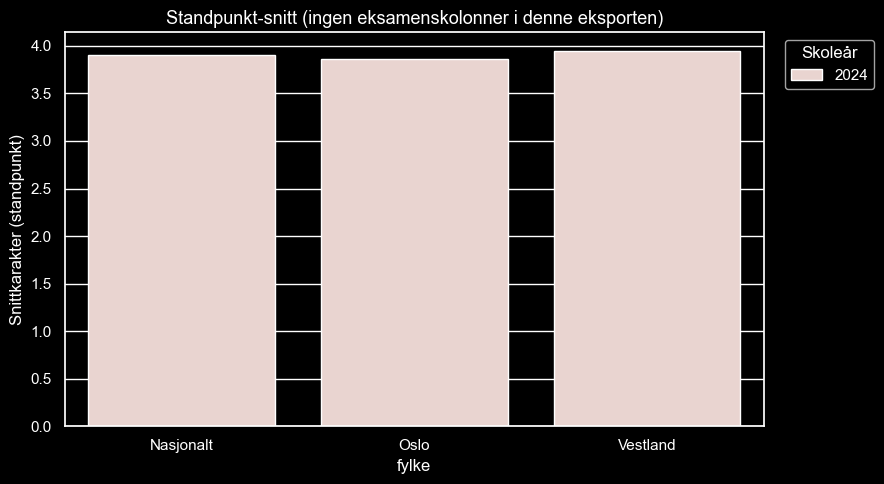

In [14]:
if "plot_recent" not in globals() or "subset_fylker" not in globals():
    raise RuntimeError(
        "plot_recent finnes ikke. Kjør avsnitt 4 (analyse) først, eller Run All."
    )

melt_gaps = plot_recent.melt(
    id_vars=["ar", "fylke"],
    value_vars=["gap_skriftlig", "gap_muntlig"],
    var_name="gap_type",
    value_name="gap",
)
melt_gaps["gap_type"] = melt_gaps["gap_type"].map(
    {"gap_skriftlig": "Skriftlig − standpunkt", "gap_muntlig": "Muntlig − standpunkt"}
)

HAS_GAP_DATA = melt_gaps["gap"].notna().any()

if HAS_GAP_DATA:
    melt_plot = melt_gaps.dropna(subset=["gap"])
    fig, ax = plt.subplots()
    sns.barplot(
        data=melt_plot,
        x="ar",
        y="gap",
        hue="fylke",
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Skoleår")
    ax.set_ylabel("Gjennomsnittlig gap (karakterpoeng)")
    ax.set_title("Gap mellom eksamen og standpunkt etter fylke")
    plt.legend(title="Fylke", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    fig2, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax2, gtype, title in zip(
        axes,
        ["gap_skriftlig", "gap_muntlig"],
        ["Skriftlig − standpunkt", "Muntlig − standpunkt"],
    ):
        sub = plot_df[["ar", "fylke", gtype]].dropna()
        for fylke in subset_fylker:
            d = sub[sub["fylke"] == fylke].sort_values("ar")
            if not d.empty:
                lbl = fylke if ax2 is axes[0] else None
                ax2.plot(d["ar"], d[gtype], marker="o", label=lbl)
        ax2.axhline(0, color="gray", linewidth=0.7)
        ax2.set_title(title)
        ax2.set_xlabel("Skoleår")
    axes[0].set_ylabel("Gap (karakterpoeng)")
    h, lbls = axes[0].get_legend_handles_labels()
    fig2.legend(h, lbls, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=len(subset_fylker))
    fig2.suptitle("Utvikling over tid: Oslo sammenlignet med nasjonalt og annet fylke")
    fig2.tight_layout()
    plt.show()
else:
    sp = plot_recent.dropna(subset=["standpunkt"])
    if sp.empty:
        print("Ingen standpunkt-data å visualisere for valgte fylker.")
    else:
        fig, ax = plt.subplots(figsize=(9, 5))
        sns.barplot(data=sp, x="fylke", y="standpunkt", hue="ar", ax=ax)
        ax.set_ylabel("Snittkarakter (standpunkt)")
        ax.set_title("Standpunkt-snitt (ingen eksamenskolonner i denne eksporten)")
        plt.legend(title="Skoleår", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()


## 6. Konklusjon (kobling til del I og II)

Arbeidet dekker kravene om å **utforske Udir-statistikk**, **navigere** etter fylke og vurderingsform (og fag via `Vurderingsfagkode` i rådata), **eksportere .csv**, og kjøre en **Python-flyt** med rensing, eventuell **sammenslåing** av filer, **transformasjon**, **beregning av gap** og **figurer**.

Når data inneholder standpunkt, skriftlig og muntlig, svarer resultatene på problemstillingen: **skriftlig** gir vanligvis **negativt gap** (eksamen under standpunkt) og **muntlig** **positivt gap** (eksamen over standpunkt), i tråd med Udirs beskrivelse. **Oslo** sammenlignes med **Nasjonalt** og et **annet fylke** for å se om mønsteret fra den offentlige debatten også gjelder regionalt.

Hvis din egen Udir-eksport bare har **standpunkt-kolonner**, må du i statistikkbanken legge til **skriftlig** og **muntlig eksamen** før nedlasting for full gap-analyse; notatet viser da standpunkt per fylke og forklarer begrensningen.

Fyll inn **dato øverst** og eventuelt `COMPARE_COUNTY` etter tilgjengelige fylker i filen din.
